In [1]:
import glob
from astropy.io import fits
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from multiprocessing import Pool, cpu_count
from functools import partial
import traceback

In [2]:
DETECTOR = 6

qr = 1
gain_file = glob.glob(f'/data1/SPHEREx/CalFiles/abs_gain_matrix_qr{qr}/*/{DETECTOR}/*.fits')[0]
gain1 = fits.open(gain_file)[1].data

qr = 2
gain_file = glob.glob(f'/data1/SPHEREx/CalFiles/abs_gain_matrix_qr{qr}/*/{DETECTOR}/*.fits')[0]
gain2 = fits.open(gain_file)[1].data

gain_factor = gain2/gain1

In [3]:
old_dirs = ['/mnt/md127/SPHEREx/reproc_data/deep_north',
            '/mnt/md124/SPHEREx/reproc_data/deep_north']
new_dir = '/mnt/md124/SPHEREx/SPHEREx_nep_data/qr1_newgain'
file_pattern = f'/*/*/*/*D{DETECTOR}*.fits'

In [4]:
def process_file(old_path, old_dir, new_dir, gain_factor):
    try:
        # Construct new path
        new_path = old_path.replace(old_dir, new_dir)
        new_folder = os.path.dirname(new_path)

        # Create directory if it doesn't exist (thread-safeish for makedirs)
        os.makedirs(new_folder, exist_ok=True)

        # Open, Calibrate, and Write
        with fits.open(old_path) as hdul:
            data = hdul[1].data
            calibrated_data = data * gain_factor
            hdul[1].data = calibrated_data
            hdul.writeto(new_path, overwrite=True)
            
        return True  # Success
        
    except Exception as e:
        print(f"Error processing {old_path}: {str(e)}")
        traceback.print_exc()
        return False

num_processes = 5

for old_dir in old_dirs:
    old_path_list = glob.glob(old_dir+file_pattern)

    print(f"Starting parallel processing with {num_processes} workers...")

    func = partial(process_file, old_dir=old_dir, new_dir=new_dir, gain_factor=gain_factor)

    with Pool(processes=num_processes) as pool:
        results = list(tqdm(pool.imap_unordered(func, old_path_list), total=len(old_path_list)))

    # Check for errors
    errors = [res for res in results if not res]
    if errors:
        print(f"\nCompleted with {len(errors)} errors:")


Starting parallel processing with 5 workers...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 4414/4414 [27:18<00:00,  2.69it/s]


Starting parallel processing with 5 workers...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 820/820 [08:37<00:00,  1.58it/s]


In [63]:
hdul = fits.open(new_path)

In [94]:
errors

[]

In [68]:
gain_factor

array([[1.1791898, 1.1790099, 1.1788304, ..., 1.1810821, 1.1812674,
        1.181452 ],
       [1.1774613, 1.1772836, 1.1771064, ..., 1.1793284, 1.1795105,
        1.1796937],
       [1.1757548, 1.1755793, 1.1754042, ..., 1.1775953, 1.1777759,
        1.1779568],
       ...,
       [1.0443842, 1.0444583, 1.0445323, ..., 1.0428299, 1.0427557,
        1.0426811],
       [1.0449579, 1.0450325, 1.0451071, ..., 1.0433946, 1.0433198,
        1.0432448],
       [1.0455354, 1.0456104, 1.0456854, ..., 1.043963 , 1.0438876,
        1.0438122]], shape=(2040, 2040), dtype=float32)

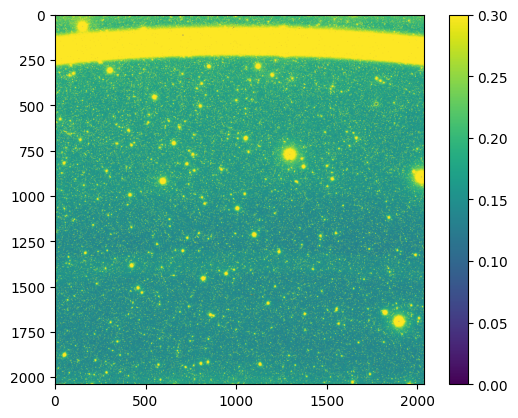

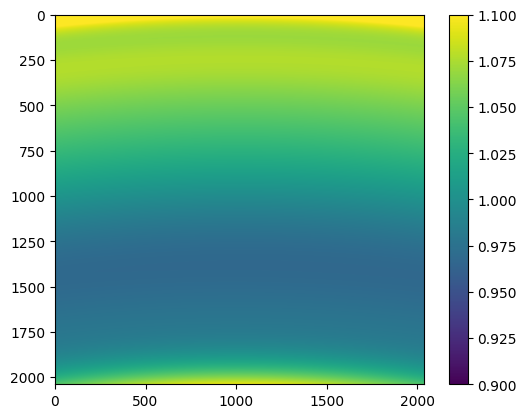

In [69]:
plt.imshow(hdul[1].data*gain_factor, vmin=0, vmax=0.3)
plt.colorbar()
plt.show()
plt.imshow(gain_factor, vmin=0.9, vmax=1.1)
plt.colorbar()
plt.show()

In [118]:
reporj_dir = '/mnt/md124/thomasli/selfcal/outputs/SPHEREx_nep_qr2_det1_6p2arcsec/reprojected/'
reproj_list = sorted(glob.glob(reporj_dir + '*.h5'))
reproj_list[-1]

'/mnt/md124/thomasli/selfcal/outputs/SPHEREx_nep_qr2_det1_6p2arcsec/reprojected/exp_013280_det_0.h5'

In [108]:
from SelfCal.MakeMap import load_reproj_file
import numpy as np

In [109]:
exp_list = []
for reproj_file in tqdm(reproj_list):
    exp_path = load_reproj_file(reproj_file, fields=['file_path'])['file_path']
    # exp_file = os.path.basename(exp_path)
    exp_list.append(exp_path)

  0%|                                                                                                                     | 0/12841 [00:00<?, ?it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 12841/12841 [02:19<00:00, 92.19it/s]


In [111]:
bad_index = [i for i, f in enumerate(exp_list) if '2025W33' in f and 'qr1' in f]
len(bad_index)

0

In [112]:
bad_index = [i for i, f in enumerate(exp_list) if '2025W33' in f and 'qr1' in f]

for i in tqdm(bad_index):
    os.remove(reproj_list[i])

reporj_dir = '/mnt/md124/thomasli/selfcal/outputs/SPHEREx_nep_qr2_det5_6p2arcsec/reprojected/'
reproj_list = sorted(glob.glob(reporj_dir + '*.h5'))

new_exp_idx = np.arange(len(reproj_list))

for new_exp_idx, reproj_file in zip(new_exp_idx, tqdm(reproj_list)):
    basename = os.path.basename(reproj_file)
    exp_idx, det_idx = int(basename.split('_')[1]),int(basename.split('_')[3].strip('.h5'))
    new_basename = f'exp_{new_exp_idx:06d}_det_{det_idx}.h5'
    new_path = os.path.join(reporj_dir, new_basename)
    os.rename(reproj_file, new_path)

0it [00:00, ?it/s]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████▉| 12840/12841 [00:00<00:00, 44594.80it/s]
